# Qaddir — Experiment 1: Baseline

### Dataset used in ALL official experiments
- Training: **1,408 images** (50% reduced training set)
- Validation: **810 images** (unchanged)
- Test: **374 images** (unchanged)
- Classes: **6**
- Model: **YOLO11n**
- Image size: **640**
- Seed: **42**
- Local GPU: **device 0**
- AMP: **False** (local MX450 compatibility)

The original `CarDD_YOLO` dataset is not modified.


In [1]:
from ultralytics import YOLO
from pathlib import Path
import time
import json

print("Qaddir official experiment")


Qaddir official experiment


In [2]:
# ============================================
# Configuration
# ============================================

DATA_YAML = Path(
    r"C:\Users\xlosn\qaddir-vehicle-damage-assessment\data\CarDD_release\CarDD_YOLO_Reduced\data.yaml"
)

RUN_DIR = Path(
    r"C:\Users\xlosn\qaddir-vehicle-damage-assessment\notebooks\runs\official_reduced\exp1"
)

EXPERIMENT_NAME = "exp1_baseline"
EPOCHS = 50
BATCH = 4

print("Dataset:", DATA_YAML)
print("Run directory:", RUN_DIR)


Dataset: C:\Users\xlosn\qaddir-vehicle-damage-assessment\data\CarDD_release\CarDD_YOLO_Reduced\data.yaml
Run directory: C:\Users\xlosn\qaddir-vehicle-damage-assessment\notebooks\runs\official_reduced\exp1


In [3]:
pip install -U ultralytics

  Using cached ultralytics-8.4.152-py3-none-any.whl.metadata (46 kB)
Using cached ultralytics-8.4.152-py3-none-any.whl (1.4 MB)
  Attempting uninstall: ultralytics
    Found existing installation: ultralytics 8.4.144
    Uninstalling ultralytics-8.4.144:
      Successfully uninstalled ultralytics-8.4.144
Note: you may need to restart the kernel to use updated packages.


In [15]:
from pathlib import Path

base = Path("/workspace/CarDD_YOLO_Reduced/CarDD_YOLO_Reduced")

for split in ["train", "val", "test"]:
    images = list((base / "images" / split).glob("*.jpg"))
    labels = list((base / "labels" / split).glob("*.txt"))

    print(f"{split}:")
    print(f"  Images: {len(images)}")
    print(f"  Labels: {len(labels)}")

train:
  Images: 1408
  Labels: 1408
val:
  Images: 810
  Labels: 810
test:
  Images: 374
  Labels: 374


In [24]:
from pathlib import Path

DATA_YAML = Path("/workspace/CarDD_YOLO_Reduced/CarDD_YOLO_Reduced/data.yaml")

yaml_content = """path: /workspace/CarDD_YOLO_Reduced/CarDD_YOLO_Reduced
train: images/train
val: images/val
test: images/test

names:
  0: dent
  1: scratch
  2: crack
  3: glass shatter
  4: lamp broken
  5: tire flat
"""

DATA_YAML.write_text(yaml_content)

print(DATA_YAML.read_text())

path: /workspace/CarDD_YOLO_Reduced/CarDD_YOLO_Reduced
train: images/train
val: images/val
test: images/test

names:
  0: dent
  1: scratch
  2: crack
  3: glass shatter
  4: lamp broken
  5: tire flat



In [22]:
from pathlib import Path

DATA_YAML = Path("/workspace/CarDD_YOLO_Reduced/CarDD_YOLO_Reduced/data.yaml")

print(DATA_YAML.read_text())

path: /workspace/CarDD_YOLO_Reduced/CarDD_YOLO_Reduced
train: images/train
val: images/val
test: images/test

names:
  0: dent
  1: scratch
  2: crack
  3: glass shatter
  4: lamp broken
  5: tire flat



In [29]:
from ultralytics import YOLO

DATA_YAML = "/workspace/CarDD_YOLO_Reduced/CarDD_YOLO_Reduced/data.yaml"

model = YOLO("yolo11n.pt")

# Load dataset configuration directly
from ultralytics.data.utils import check_det_dataset

data = check_det_dataset(DATA_YAML)

print("DATASET PATH:")
print(data["path"])

print("\nTRAIN:")
print(data["train"])

print("\nVAL:")
print(data["val"])

print("\nNAMES:")
print(data["names"])

print("\nNC:")
print(data["nc"])

DATASET PATH:
/workspace/CarDD_YOLO_Reduced/CarDD_YOLO_Reduced

TRAIN:
/workspace/CarDD_YOLO_Reduced/CarDD_YOLO_Reduced/images/train

VAL:
/workspace/CarDD_YOLO_Reduced/CarDD_YOLO_Reduced/images/val

NAMES:
{0: 'dent', 1: 'scratch', 2: 'crack', 3: 'glass shatter', 4: 'lamp broken', 5: 'tire flat'}

NC:
6


In [30]:
from pathlib import Path
from collections import Counter

labels_dir = Path(
    "/workspace/CarDD_YOLO_Reduced/CarDD_YOLO_Reduced/labels/val"
)

class_counts = Counter()

for label_file in labels_dir.glob("*.txt"):
    for line in label_file.read_text().splitlines():
        if line.strip():
            class_id = int(line.split()[0])
            class_counts[class_id] += 1

print("Class IDs found:")
for class_id, count in sorted(class_counts.items()):
    print(f"Class {class_id}: {count}")

Class IDs found:
Class 0: 501
Class 1: 728
Class 2: 177
Class 3: 135
Class 4: 141
Class 5: 62


In [33]:
import torch
from ultralytics import YOLO

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))

model = YOLO("yolo11n.pt")

print("✅ YOLO model loaded successfully.")

PyTorch: 2.8.0+cu128
CUDA available: True
GPU: NVIDIA A40
✅ YOLO model loaded successfully.


In [6]:
pip install ultralytics==8.4.152
!pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [7]:
import ultralytics
import torch

print("Ultralytics:", ultralytics.__version__)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

Ultralytics: 8.4.144
PyTorch: 2.8.0+cu128
CUDA available: True
GPU: NVIDIA A40


In [45]:
import time
# =========================
# Experiment 1 Configuration
# =========================


DATA_YAML = "/workspace/CarDD_YOLO_Reduced/CarDD_YOLO_Reduced/data.yaml"

EPOCHS = 100
BATCH = 16
IMG_SIZE = 640

PROJECT_DIR = "/workspace/runs/cardd"
EXPERIMENT_NAME = "experiment_1_reduced_baseline"


In [42]:
# =========================
# Load pretrained model
# =========================

model = YOLO("yolo11n.pt")


In [46]:
# =========================
# Start training
# =========================

start_time = time.time()

results = model.train(
    data=DATA_YAML,
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH,
    device=0,
    workers=4,

    # Reproducibility
    seed=42,
    deterministic=True,

    # Baseline: default/automatic optimizer
    optimizer="auto",

    # No custom augmentation
    degrees=0.0,
    translate=0.0,
    scale=0.0,
    fliplr=0.0,
    flipud=0.0,
    mosaic=0.0,
    mixup=0.0,
    copy_paste=0.0,

    # A40
    amp=True,

    # Experiment tracking
    project=PROJECT_DIR,
    name=EXPERIMENT_NAME,
    exist_ok=True,

    # Save results
    plots=True,
    save=True,
    verbose=True
)

elapsed_minutes = (time.time() - start_time) / 60

RUN_DIR = Path(PROJECT_DIR) / EXPERIMENT_NAME
BEST_WEIGHTS = RUN_DIR / "weights" / "best.pt"

print("\n" + "=" * 60)
print("✅ EXPERIMENT 1 COMPLETED")
print("=" * 60)
print(f"Training time: {elapsed_minutes:.2f} minutes")
print(f"Run directory: {RUN_DIR}")
print(f"Best weights: {BEST_WEIGHTS}")

New https://pypi.org/project/ultralytics/8.4.152 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.144 🚀 Python-3.12.3 torch-2.8.0+cu128 CUDA:0 (NVIDIA A40, 45488MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/workspace/CarDD_YOLO_Reduced/CarDD_YOLO_Reduced/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=

In [57]:
import pandas as pd
import matplotlib.pyplot as plt

RUN_DIR = Path("/workspace/runs/cardd/experiment_1_reduced_baseline")

results_csv = RUN_DIR / "results.csv"

df = pd.read_csv(results_csv)

# إزالة المسافات من أسماء الأعمدة
df.columns = df.columns.str.strip()

print("Columns:")
print(df.columns.tolist())

Columns:
['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']


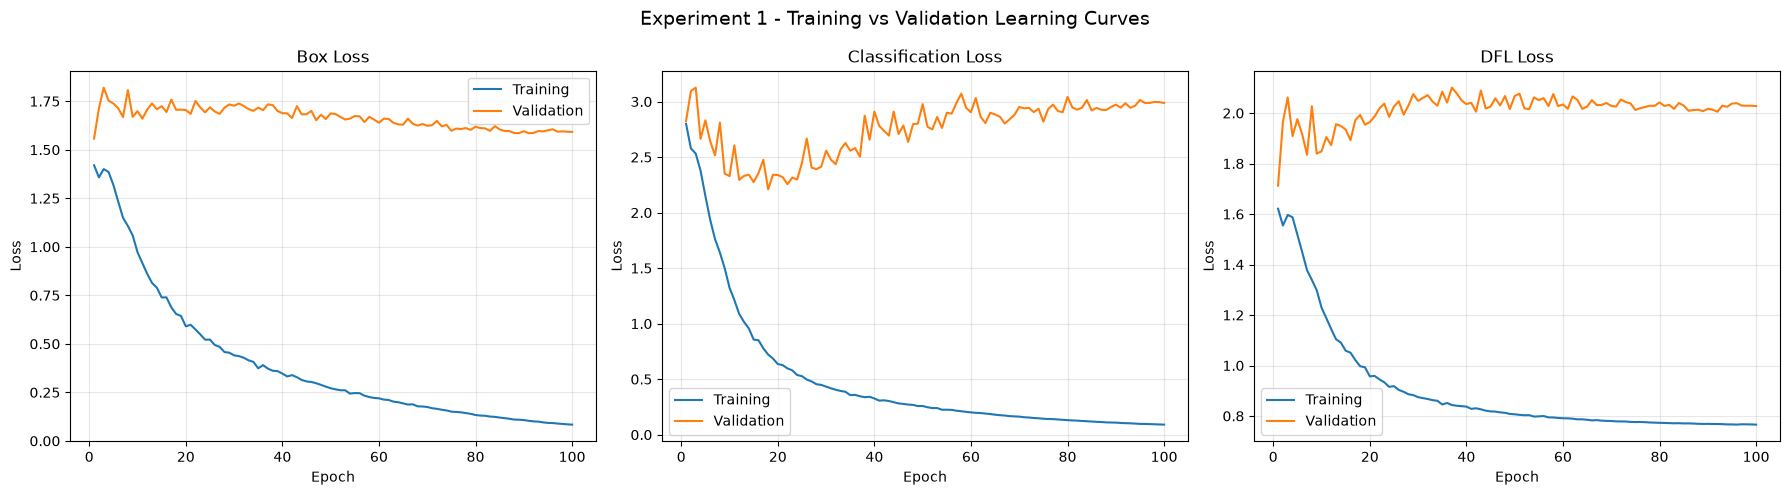

Saved to: /workspace/runs/cardd/experiment_1_reduced_baseline/learning_curves.png


In [58]:
# =========================
# Learning Curves
# =========================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

losses = [
    ("box_loss", "Box Loss"),
    ("cls_loss", "Classification Loss"),
    ("dfl_loss", "DFL Loss")
]

for ax, (loss, title) in zip(axes, losses):

    ax.plot(
        df["epoch"],
        df[f"train/{loss}"],
        label="Training"
    )

    ax.plot(
        df["epoch"],
        df[f"val/{loss}"],
        label="Validation"
    )

    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle(
    "Experiment 1 - Training vs Validation Learning Curves",
    fontsize=14
)

plt.tight_layout()

# Save figure
output_path = RUN_DIR / "learning_curves.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Saved to: {output_path}")

In [59]:
from pathlib import Path
import pandas as pd

RUN_DIR = Path("/workspace/runs/cardd/experiment_1_reduced_baseline")

results_csv = RUN_DIR / "results.csv"

df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()

# Best epoch based on mAP50-95
best_idx = df["metrics/mAP50-95(B)"].idxmax()
best_row = df.loc[best_idx]

summary = {
    "Experiment": "Experiment 1 - Reduced Baseline",
    "Model": "YOLO11n",
    "Dataset": "CarDD Reduced",
    "Train Images": 1408,
    "Validation Images": 810,
    "Epochs": 100,
    "Image Size": 640,
    "Batch Size": 16,
    "Optimizer": "Auto",
    "AMP": True,
    "Seed": 42,
    "Best Epoch": int(best_row["epoch"]),
    "Precision": best_row["metrics/precision(B)"],
    "Recall": best_row["metrics/recall(B)"],
    "mAP50": best_row["metrics/mAP50(B)"],
    "mAP50-95": best_row["metrics/mAP50-95(B)"],
    "Training Time (min)": 21.17
}

summary_df = pd.DataFrame([summary])

display(summary_df)

# Save
summary_path = RUN_DIR / "experiment_1_summary.csv"
summary_df.to_csv(summary_path, index=False)

print(f"\n✅ Summary saved to:")
print(summary_path)

,Experiment,Model,Dataset,Train Images,Validation Images,Epochs,Image Size,Batch Size,Optimizer,AMP,Seed,Best Epoch,Precision,Recall,mAP50,mAP50-95,Training Time (min)
0,Experiment 1 - Reduced Baseline,YOLO11n,CarDD Reduced,1408,810,100,640,16,Auto,True,42,75,0.63269,0.49838,0.49928,0.38871,21.17



✅ Summary saved to:
/workspace/runs/cardd/experiment_1_reduced_baseline/experiment_1_summary.csv
